# Kvalitetskontroll: hva som ikke overlever

Arbeidsverk 2, notebook 07. Leser notebook 01 til 06 som om de var skrevet av noen andre.

De seks notebookene forhåndsregistrerte til sammen nitten påstander og gjorde opp for
hver av dem. Det gjør dem kontrollerbare på en måte de fleste analyser ikke er: når
påstanden og avgjørelseskriteriet står nedskrevet før tallene finnes, kan man i
ettertid spørre om **avgjørelsen ble tatt med riktig instrument**.

Denne notebooken stiller det spørsmålet for de seks konklusjonene som bærer mest vekt.
Fem av dem ble avgjort med et instrument som ikke tåler forutsetningene i dette
datagrunnlaget. To hovedpåstander må trekkes tilbake. Én blir sterkere når den regnes
riktig. Resten står, men med et smalere gyldighetsområde enn de ble gitt.

Ingenting slettes i notebook 01–06. Feilene og rettelsene ligger ved siden av hverandre,
fordi et arbeid som bare viser det som holdt, ikke lar seg etterprøve.

**Det som kontrolleres her, og utfallet:**

| | Kontroll | Rammer | Utfall |
|---|---|---|---|
| K1 | Nøstede modeller testet med Diebold–Mariano | nb03, nb04 | påstand trekkes |
| K2 | Tverrsnittsavhengighet i bydelstesten | nb06 | påstand trekkes |
| K3 | Endelig-utvalgskorreksjonen anvendt bakover | nb02 | funn står, tolkning endres |
| K4 | Utbyttbarhet i panelkalibreringen | nb05 | påstand innsnevres |
| K5 | En kontroll som ikke kunne feile | nb03 | kontroll erstattes |
| K6 | Tellinger og indre motsigelser | nb01, nb04 | fire rettelser |


## 1. Oppsett

Samme datagrunnlag, samme protokoll, samme frø som notebook 03 til 06. Modellene
tilpasses på nytt her framfor å leses inn, slik at kontrollen ikke arver noe fra
kjøringen den kontrollerer.


In [1]:
import os, subprocess, sys

def git(*a, standard=None):
    try:
        return subprocess.run(["git", *a], capture_output=True, text=True,
                              check=True, cwd=REPO).stdout.strip()
    except Exception:
        return standard

REPO = "/content/bostotte-oslo" if os.path.isdir("/content/bostotte-oslo") else "."
if not os.path.isdir(os.path.join(REPO, "data")):
    subprocess.run(["git", "clone", "--depth", "1",
                    "https://github.com/Torcode/bostotte-oslo.git",
                    "/content/bostotte-oslo"], check=True)
    REPO = "/content/bostotte-oslo"
elif REPO.startswith("/content"):
    git("fetch", "--depth", "1", "origin", "main"); git("reset", "--hard", "origin/main")

try: import torch
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "torch"], check=True)
    import torch

COMMIT, UTTREKK = git("rev-parse", "--short", "HEAD", standard="ukjent"), "2026-08-04"
print("repo    :", os.path.abspath(REPO))
print("commit  :", COMMIT)
print("uttrekk :", UTTREKK)


repo    : /home/claude/bostotte-oslo
commit  : 59b0409
uttrekk : 2026-08-04


In [2]:
# harmoni-med-git: denne cellen holdes utenfor sitt eget avtrykk
import hashlib, json, urllib.request, urllib.error

KILDEAVTRYKK = "b7947ca4dc3da44d4eb16ae973e4f818c15f023530e0e437a902226d4a3fc372"
RAATT = ("https://raw.githubusercontent.com/Torcode/bostotte-oslo/"
         "main/notebooks/bostotte_07_kvalitetskontroll.ipynb")
LOGG  = ("https://api.github.com/repos/Torcode/bostotte-oslo/commits"
         "?path=notebooks/bostotte_07_kvalitetskontroll.ipynb&per_page=1")

def kildeavtrykk(celler):
    ut = []
    for c in celler:
        kilde = c["source"] if isinstance(c["source"], str) else "".join(c["source"])
        if "harmoni-med-git" not in kilde:
            ut.append(kilde)
    return hashlib.sha256("\n".join(ut).encode("utf-8")).hexdigest()

def hent(url, sekunder=25):
    with urllib.request.urlopen(url, timeout=sekunder) as r:
        return json.load(r)

try:    NAAR = " (sist endret " + hent(LOGG)[0]["commit"]["committer"]["date"][:10] + ")"
except Exception: NAAR = ""

try:
    paa_main = kildeavtrykk(hent(RAATT)["cells"])
    I_HARMONI = paa_main == KILDEAVTRYKK
    MANIFEST_HARMONI = "i harmoni" if I_HARMONI else "avvik mot main"
    print(f"I harmoni med main{NAAR}." if I_HARMONI else
          f"AVVIK mot main: denne {KILDEAVTRYKK[:16]}..., main {paa_main[:16]}...{NAAR}")
except urllib.error.HTTPError as e:
    MANIFEST_HARMONI = ("finnes ikke paa main" if e.code == 404
                        else f"ikke sjekket (HTTP {e.code})")
    print("Notebooken ligger ikke paa main ennaa." if e.code == 404
          else f"Kontrollen fikk HTTP {e.code}. Anta at kopien kan vaere utdatert.")
except Exception as e:
    MANIFEST_HARMONI = f"ikke sjekket ({type(e).__name__})"
    print(f"Kontrollen naadde ikke GitHub ({type(e).__name__}); anta at kopien er utdatert.")


Notebooken ligger ikke paa main ennaa.


In [3]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt, time
import torch.nn as nn
from scipy import stats
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression

SEED = 20260807
np.random.seed(SEED); torch.manual_seed(SEED)
torch.set_num_threads(max(1, os.cpu_count()))
plt.rcParams.update({"figure.dpi": 130, "font.size": 9, "axes.grid": True,
                     "grid.alpha": 0.25, "axes.spines.top": False,
                     "axes.spines.right": False})
BLAA, ROED, GRAA, GRONN = "#1f4e79", "#a83232", "#7a7a7a", "#2e6b47"

RAW = os.path.join(REPO, "data/raw/")
raa = pd.read_csv(RAW + "husbanken_bostotte_oslo_manedlig.csv")
raa["dato"] = pd.to_datetime(dict(year=raa.aar, month=raa.manedsnr, day=1))
raa = raa.sort_values("dato").reset_index(drop=True)
kant = raa.index[(raa.dato == raa.dato.max()) & (raa.ant_husstander_termin == 0)]
est = raa.drop(index=kant)
est = est[est.dato >= "2017-01-01"].reset_index(drop=True)
M = est.set_index("dato")["ant_husstander_termin"].astype(float)
LOG_M = np.log(M)
N_EST, MIN_TR, H = len(est), 72, 12
OPPRINNELSER = [est.dato.iloc[i-1] for i in range(1, N_EST+1) if MIN_TR <= i <= N_EST - H]
NEVNER = {t0: np.abs(M.loc[:t0].values[12:] - M.loc[:t0].values[:-12]).mean()
          for t0 in OPPRINNELSER}
print(f"{N_EST} maaneder i estimasjonsvinduet, {len(OPPRINNELSER)} opprinnelser, "
      f"h = 1..{H}, {len(OPPRINNELSER)*H} prognosepunkter per modell")


114 maaneder i estimasjonsvinduet, 31 opprinnelser, h = 1..12, 372 prognosepunkter per modell


In [4]:
mnd_alle = pd.date_range("2010-01-01", "2027-12-01", freq="MS")
X = pd.DataFrame(index=mnd_alle)
X["win_covid"] = ((mnd_alle >= "2020-04-01") & (mnd_alle <= "2020-10-01")).astype(int)
X["win_strom"] = ((mnd_alle >= "2021-12-01") & (mnd_alle <= "2024-03-01")).astype(int)
X["pakke_2024h2"] = (((mnd_alle >= "2024-07-01").astype(int)
                      + (mnd_alle >= "2024-09-01").astype(int)
                      + (mnd_alle >= "2024-10-01").astype(int)) / 3)

def u_av_fase(fase=0, fra=pd.Timestamp("2010-01-01"), til=pd.Timestamp("2027-12-31")):
    anker = pd.Timestamp("2014-01-06") + pd.Timedelta(days=fase)
    start = anker - pd.Timedelta(days=14*int(np.ceil((anker - fra).days/14)))
    d = pd.date_range(start, til, freq="14D"); d = d[d >= fra]
    return pd.Series(d).dt.to_period("M").dt.to_timestamp().value_counts().sort_index()

u = u_av_fase(0).reindex(mnd_alle)
X["k_pre"]  = (u - 26/12) * (mnd_alle <= "2024-12-01").astype(int)
X["k_post"] = (u - 26/12) * (mnd_alle >= "2025-01-01").astype(int)
REG, MIN_NZ, LAG = list(X.columns), 6, [1, 2, 3, 6, 11, 12]

def trekk(serie, s, framtidslekk=0):
    # framtidslekk > 0 brukes bare av mutasjonstesten i K5.
    v = serie.loc[:s] if framtidslekk == 0 else serie.loc[:s + pd.DateOffset(months=framtidslekk)]
    if len(v) < 13:
        return None
    d = np.diff(np.log(v.values))
    ut = {f"lag{l}": np.log(v.iloc[-1-l]) - np.log(v.iloc[-1]) for l in LAG}
    ut["niva"]   = np.log(v.iloc[-1]); ut["d1"] = d[-1]
    ut["d12"]    = np.log(v.iloc[-1]) - np.log(v.iloc[-13])
    ut["sd6"]    = d[-6:].std(); ut["sd12"] = d[-12:].std(); ut["snitt6"] = d[-6:].mean()
    return ut

def rad(serie, s, maalmnd, aktive):
    f = trekk(serie, s)
    if f is None: return None
    f = dict(f); f["mnd"] = maalmnd.month
    for r in REG: f[r] = X.loc[maalmnd, r] if r in aktive else 0.0
    return f

def treningssett(serie, t0, h, aktive, slakk=0):
    # slakk > 0 brukes bare av mutasjonstesten i K5.
    rader, y, anker, maalmnd = [], [], [], []
    for s in serie.index:
        m_ = s + pd.DateOffset(months=h)
        if m_ > t0 + pd.DateOffset(months=slakk) or m_ not in serie.index:
            continue
        f = rad(serie, s, m_, aktive)
        if f is None: continue
        rader.append(f); y.append(np.log(serie.loc[m_]))
        anker.append(np.log(serie.loc[s])); maalmnd.append(m_)
    return pd.DataFrame(rader), np.array(y), np.array(anker), pd.DatetimeIndex(maalmnd)

byd = pd.read_csv(RAW + "husbanken_bostotte_oslo_bydel_manedlig.csv", dtype={"kommunenr": str})
byd["dato"] = pd.to_datetime(dict(year=byd.aar, month=byd.manedsnr, day=1))
byd_nz = byd[byd.ant_husstander_termin > 0]
PANEL = {k: g.set_index("dato")["ant_husstander_termin"].astype(float).sort_index()
         for k, g in byd_nz.groupby("kommunenr") if k != "0301"}
PANEL = {k: v[v.index >= "2017-01-01"] for k, v in PANEL.items()}
SERIER = {"OSLO": M, **PANEL}
REKKE  = ["OSLO"] + sorted(PANEL)
print(f"{len(REKKE)} serier i panelet: Oslo + {len(PANEL)} bydeler")


16 serier i panelet: Oslo + 15 bydeler


## 2. K1 — En nøstet sammenlikning avgjort med feil test

Notebook 03 sammenlikner de trebaserte modellene med den naive prognosen og
konkluderer med at ingen av dem skiller seg fra den. Konklusjonen er gjentatt i
notebook 04 og i endringsloggen.

Sammenlikningen er **nøstet**. Alle modellene i stigen har formen

$$\hat y_{t+h} = \underbrace{\log y_t}_{\text{anker}} + f(x_t),$$

og den naive prognosen M0 er nøyaktig det samme uttrykket med $f \equiv 0$. Den er
altså ikke en annen modell, men den samme modellen med en parameterrestriksjon.

Under nullhypotesen om at $f$ ikke har noe å bidra med, estimerer den store modellen
likevel $f$, og betaler for det i økt varians. Diebold–Mariano regner den kostnaden som
bevis for at den lille modellen er bedre. Clark og West (2007) viser at korreksjonsleddet
$(e_1 - e_2)^2$ er akkurat den kostnaden, og at differansen

$$d_t = e_{1t}^2 - \left(e_{2t}^2 - (e_{1t} - e_{2t})^2\right)$$

har forventning null under nullhypotesen. Testen er ensidig av konstruksjon.

Notebook 02 skrev regelen ned — *«Clark–West brukes der den ene modellen er nøstet i den
andre»* — og implementerte den som `noestet=True`. Notebook 03 kalte funksjonen uten
argumentet. Regelen sto, grenen var skrevet, og ingen av delene ble brukt.


In [5]:
def statistikk(e1, e2, h, noestet):
    n = len(e1)
    d = e1**2 - (e2**2 - (e1 - e2)**2) if noestet else e1**2 - e2**2
    dc = d - d.mean()
    gamma = np.array([(dc[:n-k]*dc[k:]).sum()/n for k in range(h)])
    v = (gamma[0] + 2*gamma[1:].sum())/n
    if not np.isfinite(v) or v <= 0:
        return np.nan
    return (d.mean()/np.sqrt(v)) * np.sqrt((n + 1 - 2*h + h*(h - 1)/n)/n)

PARAM = dict(n_estimators=300, max_depth=3, learning_rate=0.05, subsample=0.8,
             colsample_bytree=0.8, min_child_weight=5, reg_lambda=1.0,
             random_state=SEED, n_jobs=4, verbosity=0)

def globalt(t0, h, aktive, Xtr, ytr, ank):
    Xs, ys = [Xtr], [ytr - ank]
    for s in PANEL.values():
        a, b, c, _ = treningssett(s, t0, h, aktive)
        if len(a): Xs.append(a[Xtr.columns]); ys.append(b - c)
    return pd.concat(Xs, ignore_index=True), np.concatenate(ys)

t_start, rader = time.time(), []
for t0 in OPPRINNELSER:
    aktive = [r for r in REG if (X.loc[M.loc[:t0].index, r] != 0).sum() >= MIN_NZ]
    for h in range(1, H + 1):
        m_ = t0 + pd.DateOffset(months=h)
        Xtr, ytr, ank, maal = treningssett(M, t0, h, aktive)
        Xpr = pd.DataFrame([rad(M, t0, m_, aktive)])[Xtr.columns]
        ankpr = LOG_M.loc[t0]
        ut = dict(opprinnelse=t0, h=h, dato=m_, sant=M.loc[m_], q=NEVNER[t0], M0=ankpr,
                  n_trening=len(Xtr), maal_seneste=maal.max())
        ut["G1"] = ankpr + float(XGBRegressor(**PARAM).fit(Xtr, ytr - ank).predict(Xpr)[0])
        Xg, yg = globalt(t0, h, aktive, Xtr, ytr, ank)
        ut["G2"] = ankpr + float(XGBRegressor(**PARAM).fit(Xg, yg).predict(Xpr)[0])
        ols = LinearRegression().fit(Xtr[aktive], ytr)
        rest = ytr - ols.predict(Xtr[aktive])
        ut["N1"] = (float(ols.predict(Xpr[aktive])[0])
                    + float(XGBRegressor(**PARAM).fit(Xtr, rest).predict(Xpr)[0]))
        rader.append(ut)
R = pd.DataFrame(rader)
print(f"{len(R)} punkter tilpasset paa nytt paa {time.time()-t_start:.0f} s")
for m in ["M0", "G1", "G2", "N1"]:
    e = R.sant - np.exp(R[m])
    print(f"  {m}: MASE {np.mean(np.abs(e)/R.q):.3f}")


372 punkter tilpasset paa nytt paa 260 s
  M0: MASE 1.003
  G1: MASE 0.905
  G2: MASE 0.815
  N1: MASE 1.066


In [6]:
NOSTEDE = [("M0", "G1"), ("M0", "G2"), ("M0", "N1")]
HH = list(range(1, H + 1))

def tabell(noestet):
    ut = {}
    for a, b in NOSTEDE:
        kol = []
        for h in HH:
            x = R[R.h == h]
            kol.append(statistikk((x.sant - np.exp(x[a])).values,
                                  (x.sant - np.exp(x[b])).values, h, noestet))
        ut[f"{a} mot {b}"] = kol
    return pd.DataFrame(ut, index=pd.Index(HH, name="h"))

DM, CW = tabell(False), tabell(True)
KRIT = 1.64
sml = pd.concat({"Diebold-Mariano": DM.loc[[1, 3, 6, 12]],
                 "Clark-West": CW.loc[[1, 3, 6, 12]]}, axis=1).round(2)
print(f"Ensidig kritisk verdi {KRIT}. Positiv verdi favoriserer modellen til hoeyre.\n")
print(f"Over {KRIT}: {int((DM.values > KRIT).sum())} av {DM.size} celler med DM, "
      f"{int((CW.values > KRIT).sum())} av {CW.size} med Clark-West.\n")
sml


Ensidig kritisk verdi 1.64. Positiv verdi favoriserer modellen til hoeyre.

Over 1.64: 0 av 36 celler med DM, 13 av 36 med Clark-West.



Diebold-Mariano                     Clark-West                    
         M0 mot G1 M0 mot G2 M0 mot N1  M0 mot G1 M0 mot G2 M0 mot N1
h                                                                    
1             0.89      1.01      0.25       1.84      1.71      1.14
3             0.79      1.40      0.08       1.78      2.30      0.96
6             0.07      0.76     -0.27       1.00      1.61      0.84
12            0.05      0.34      0.07       1.23      1.36      1.29

Tabellen viser de fire horisontene notebook 03 rapporterte. Figuren under viser alle
tolv, fordi utvalget av horisonter er et valg som kan gjøre mye med et bilde.


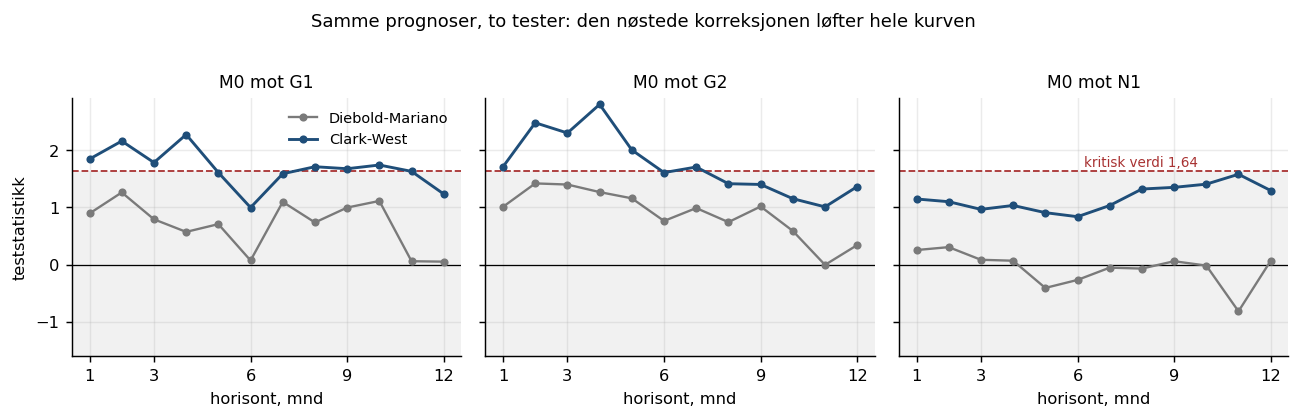

In [7]:
fig, akser = plt.subplots(1, 3, figsize=(10.2, 3.1), sharey=True)
for ax, (a, b) in zip(akser, NOSTEDE):
    n = f"{a} mot {b}"
    ax.axhspan(-3, KRIT, color=GRAA, alpha=0.10, lw=0)
    ax.axhline(KRIT, color=ROED, lw=1.0, ls="--")
    ax.axhline(0, color="k", lw=0.7)
    ax.plot(HH, DM[n], "o-", color=GRAA, ms=3.5, lw=1.3, label="Diebold-Mariano")
    ax.plot(HH, CW[n], "o-", color=BLAA, ms=3.5, lw=1.6, label="Clark-West")
    ax.set_title(n, fontsize=9.5); ax.set_xlabel("horisont, mnd")
    ax.set_xticks([1, 3, 6, 9, 12])
akser[0].set_ylabel("teststatistikk"); akser[0].set_ylim(-1.6, 2.9)
akser[0].legend(frameon=False, fontsize=8, loc="upper right")
akser[2].text(6.2, KRIT + 0.08, "kritisk verdi 1,64", color=ROED, fontsize=7.5)
fig.suptitle("Samme prognoser, to tester: den nøstede korreksjonen løfter hele kurven",
             y=1.02, fontsize=10)
fig.tight_layout(); plt.show()


**Hva vi ser på.** Tre paneler, ett per nøstet par. Den grå kurven er testen notebook 03
brukte; den blå er den som hører til en nøstet sammenlikning. Det skyggelagte feltet er
området der nullhypotesen ikke forkastes.

Avstanden mellom kurvene er ikke støy. Den er korreksjonsleddet
$\mathbb{E}[(e_1 - e_2)^2]$, som er positivt for hvert eneste punkt per konstruksjon, og
som vokser med hvor mye de to prognosene skiller lag. Derfor ligger den blå kurven over
den grå overalt, og derfor er avstanden størst der modellen beveger seg mest bort fra
ankeret. Det er ikke to måleresultater å velge mellom: det ene er skjevt for denne
sammenlikningen, det andre er ikke.

**Hva som faller.** Notebook 03 og notebook 04 sier at ingen trebasert modell skiller seg
fra den naive med en statistikk over 1,64. Med den grå kurven stemmer det. Med den blå
gjør det ikke det: både G1 og G2 passerer på h = 1 og h = 3.

**Hva som står i stedet.** På én og tre måneder finner treet noe den naive prognosen ikke
har, og forskjellen er større enn støyen. Fra seks måneder og utover gjør den ikke det.
Det er en skarpere konklusjon enn den opprinnelige, og den peker samme vei som resten av
arbeidet: informasjonen i denne serien er kortsiktig.

**Hva som ikke følger.** Clark–West avviser at de ekstra leddene er null i populasjonen.
Det er ikke det samme som at den estimerte modellen prognostiserer bedre enn ankeret i
praksis — testen legger tilbake nettopp den estimasjonskostnaden man faktisk betaler.
Rangeringen på MASE er fortsatt det målet som svarer på om modellen er verdt å bruke, og
der ligger G2 på 0,82 mot M0s 1,00. De to tallene sier ulike ting og skal ikke slås sammen.


## 3. K2 — 465 observasjoner som er 31

Notebook 06 finner at avstemming forbedrer bydelsprognosene, kaller det den sterkeste
effekten i hele arbeidsverk 2, og oppgir en teststatistikk på 5,4 ved h = 1.

Tallet kommer fra å stable tapsdifferansene for femten bydeler i én vektor og teste den
som om den hadde 465 uavhengige observasjoner. Bydelene i Oslo beveger seg imidlertid i
takt — notebook 01 målte effektiv dimensjon 1,19 av 15 og brukte nettopp det til å
begrunne at avstemming ikke ville hjelpe toppen. Den samme avhengigheten ble ikke tatt
med da frihetsgradene skulle telles noen celler senere.

Cellen under bygger basisprognosene for hele hierarkiet på nytt, og måler så hvor
avhengige tapsdifferansene faktisk er, før den regner testen på nytt med klynging på
opprinnelse.


In [8]:
KOL_T = list(pd.DataFrame([trekk(M, M.index[20])]).columns) + ["mnd"] + REG
HIST = {}
for k, v in SERIER.items():
    r = {s: trekk(v, s) for s in v.index}
    HIST[k] = pd.DataFrame({s: t for s, t in r.items() if t is not None}).T

def sett(navn, t0, h, aktive):
    s, hh = SERIER[navn], HIST[navn]
    kilder = hh.index[hh.index + pd.DateOffset(months=h) <= t0]
    kilder = kilder[[k + pd.DateOffset(months=h) in s.index for k in kilder]]
    if len(kilder) == 0: return None, None
    maal = kilder + pd.DateOffset(months=h)
    D = hh.loc[kilder].copy(); D["mnd"] = maal.month
    for r in REG: D[r] = X.loc[maal, r].values if r in aktive else 0.0
    return (D[KOL_T].to_numpy(dtype=float),
            np.log(s.loc[maal].values) - np.log(s.loc[kilder].values))

def prad(navn, t0, h, aktive):
    m_ = t0 + pd.DateOffset(months=h)
    if t0 not in HIST[navn].index or m_ not in SERIER[navn].index: return None
    d = HIST[navn].loc[[t0]].copy(); d["mnd"] = m_.month
    for r in REG: d[r] = X.loc[m_, r] if r in aktive else 0.0
    return d[KOL_T].to_numpy(dtype=float)

EPOKER, LR, WD = 400, 1e-2, 1e-4
def tren_lineaer(Xg, yg, Xpr):
    mx, sx = Xg.mean(0), Xg.std(0) + 1e-9
    my, sy = yg.mean(), yg.std() + 1e-9
    Xn = torch.tensor((Xg - mx)/sx, dtype=torch.float32)
    yn = torch.tensor((yg - my)/sy, dtype=torch.float32).view(-1, 1)
    Pn = torch.tensor((Xpr - mx)/sx, dtype=torch.float32)
    torch.manual_seed(SEED)
    m = nn.Linear(Xn.shape[1], 1)
    opt = torch.optim.Adam(m.parameters(), lr=LR, weight_decay=WD); f = nn.MSELoss()
    for _ in range(EPOKER):
        opt.zero_grad(); f(m(Xn), yn).backward(); opt.step()
    m.eval()
    with torch.no_grad():
        return m(Pn).numpy().ravel()*sy + my

t_start, rad_h = time.time(), []
for t0 in OPPRINNELSER:
    aktive = [r for r in REG if (X.loc[M.loc[:t0].index, r] != 0).sum() >= MIN_NZ]
    for h in range(1, H + 1):
        Xs, ys = [], []
        for navn in REKKE:
            a, b = sett(navn, t0, h, aktive)
            if a is not None: Xs.append(a); ys.append(b)
        navn_pr, Xpr = [], []
        for navn in REKKE:
            p = prad(navn, t0, h, aktive)
            if p is not None: navn_pr.append(navn); Xpr.append(p)
        v = tren_lineaer(np.vstack(Xs), np.concatenate(ys), np.vstack(Xpr))
        m_ = t0 + pd.DateOffset(months=h)
        for i, navn in enumerate(navn_pr):
            rad_h.append(dict(serie=navn, opprinnelse=t0, h=h, dato=m_,
                              sant=float(SERIER[navn].loc[m_]),
                              pred=float(np.exp(np.log(SERIER[navn].loc[t0]) + v[i]))))
RH = pd.DataFrame(rad_h)
print(f"{len(RH)} basisprognoser for {RH.serie.nunique()} noder paa {time.time()-t_start:.0f} s")


5952 basisprognoser for 16 noder paa 80 s


In [9]:
BUNN = [k for k in REKKE if k != "OSLO"]
NODER = ["OSLO"] + BUNN
S = np.vstack([np.ones(len(BUNN)), np.eye(len(BUNN))])

P = RH.pivot(index=["opprinnelse", "h"], columns="serie", values="pred")[NODER]
Y = RH.pivot(index=["opprinnelse", "h"], columns="serie", values="sant")[NODER]
idx = P.index
hv = np.array([h for _, h in idx])

def mint(yhat, W):
    Wi = np.linalg.pinv(W)
    return S @ (np.linalg.pinv(S.T @ Wi @ S) @ S.T @ Wi @ yhat)

AVSTEMT = np.vstack([mint(P.values[i], np.eye(len(NODER))) for i in range(len(idx))])

# Tapsdifferanse per bydel: positivt naar avstemming er bedre.
DIFF = np.zeros((len(idx), len(BUNN)))
for j in range(1, len(NODER)):
    DIFF[:, j-1] = (P.values[:, j] - Y.values[:, j])**2 - (AVSTEMT[:, j] - Y.values[:, j])**2

KORR = np.corrcoef(DIFF, rowvar=False)
iu = np.triu_indices(len(BUNN), 1)
ev = np.linalg.eigvalsh(KORR)
EFF_DIM = float(ev.sum()**2/(ev**2).sum())
print(f"Snittkorrelasjon mellom bydelenes tapsdifferanser : {KORR[iu].mean():.3f}")
print(f"Spenn                                            : "
      f"{KORR[iu].min():.2f} til {KORR[iu].max():.2f}")
print(f"Effektiv dimensjon (deltakelsesforhold)          : {EFF_DIM:.2f} av {len(BUNN)}")


Snittkorrelasjon mellom bydelenes tapsdifferanser : 0.811
Spenn                                            : 0.33 til 0.97
Effektiv dimensjon (deltakelsesforhold)          : 1.43 av 15


In [10]:
def dm_stablet(h):
    m = hv == h
    d = DIFF[m].T.ravel()
    n = len(d); dc = d - d.mean()
    g = np.array([(dc[:n-k]*dc[k:]).sum()/n for k in range(h)])
    v = (g[0] + 2*g[1:].sum())/n
    return (d.mean()/np.sqrt(v)) * np.sqrt((n + 1 - 2*h + h*(h-1)/n)/n)

def dm_klynge(h):
    # Én observasjon per opprinnelse: snittet av tapsdifferansen over bydelene.
    d = DIFF.mean(axis=1)[hv == h]
    n = len(d); dc = d - d.mean()
    g = np.array([(dc[:n-k]*dc[k:]).sum()/n for k in range(h)])
    v = (g[0] + 2*g[1:].sum())/n
    return (d.mean()/np.sqrt(v)) * np.sqrt((n + 1 - 2*h + h*(h-1)/n)/n)

K2 = pd.DataFrame({"stablet (n = 465)": [dm_stablet(h) for h in HH],
                   "klynget paa opprinnelse (n = 31)": [dm_klynge(h) for h in HH]},
                  index=pd.Index(HH, name="h"))
q_b = {k: {t0: np.abs(SERIER[k].loc[:t0].values[12:] - SERIER[k].loc[:t0].values[:-12]).mean()
           for t0 in OPPRINNELSER} for k in BUNN}
def mase_bunn(Yhat):
    ut = []
    for j, k in enumerate(BUNN, start=1):
        q = np.array([q_b[k][t0] for t0, _ in idx])
        ut.append(np.mean(np.abs(Yhat[:, j] - Y.values[:, j])/q))
    return float(np.mean(ut))
print(f"Gjennomsnittlig MASE over bydelene: basis {mase_bunn(P.values):.3f} "
      f"-> avstemt {mase_bunn(AVSTEMT):.3f}\n")
print(f"Over 1,64: {int((K2.iloc[:,0] > KRIT).sum())} av 12 horisonter stablet, "
      f"{int((K2.iloc[:,1] > KRIT).sum())} av 12 klynget.\n")
K2.loc[[1, 3, 6, 12]].round(2)


Gjennomsnittlig MASE over bydelene: basis 0.836 -> avstemt 0.797

Over 1,64: 12 av 12 horisonter stablet, 1 av 12 klynget.



,stablet (n = 465),klynget paa opprinnelse (n = 31)
h,,
1,5.38,1.56
3,5.64,1.67
6,4.27,1.21
12,2.99,0.91


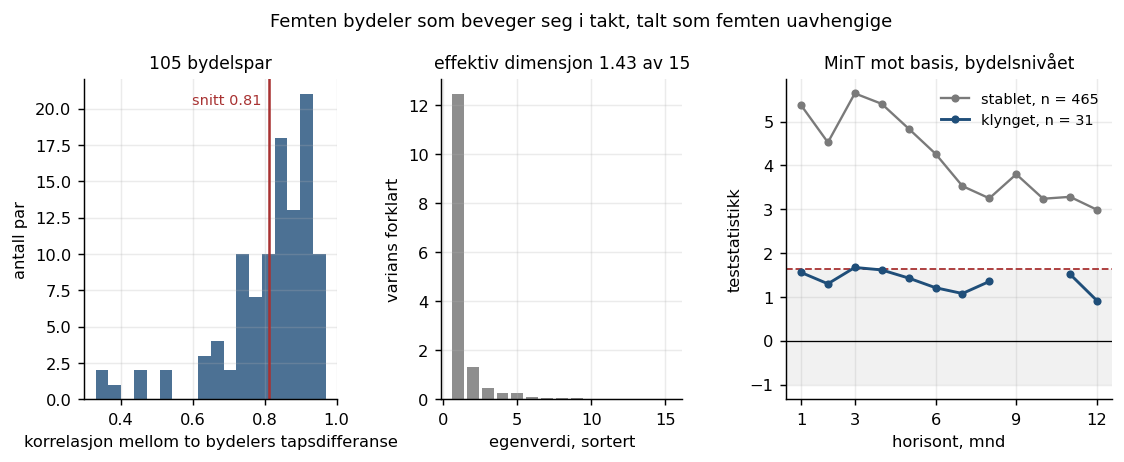

In [11]:
fig = plt.figure(figsize=(10.2, 3.2))
g = fig.add_gridspec(1, 3, width_ratios=[1.05, 1.0, 1.35], wspace=0.38)

ax0 = fig.add_subplot(g[0])
ax0.hist(KORR[iu], bins=18, color=BLAA, alpha=0.8)
ax0.axvline(KORR[iu].mean(), color=ROED, lw=1.4)
ax0.text(KORR[iu].mean() - 0.02, ax0.get_ylim()[1]*0.92, f"snitt {KORR[iu].mean():.2f}",
         color=ROED, fontsize=8, ha="right")
ax0.set_xlabel("korrelasjon mellom to bydelers tapsdifferanse")
ax0.set_ylabel("antall par"); ax0.set_title("105 bydelspar", fontsize=9.5)

ax1 = fig.add_subplot(g[1])
ax1.bar(range(1, len(ev)+1), np.sort(ev)[::-1], color=GRAA, alpha=0.85)
ax1.set_xlabel("egenverdi, sortert"); ax1.set_ylabel("varians forklart")
ax1.set_title(f"effektiv dimensjon {EFF_DIM:.2f} av 15", fontsize=9.5)

ax2 = fig.add_subplot(g[2])
ax2.axhspan(-1, KRIT, color=GRAA, alpha=0.10, lw=0)
ax2.axhline(KRIT, color=ROED, lw=1.0, ls="--"); ax2.axhline(0, color="k", lw=0.7)
ax2.plot(HH, K2.iloc[:, 0], "o-", color=GRAA, ms=3.5, lw=1.3, label="stablet, n = 465")
ax2.plot(HH, K2.iloc[:, 1], "o-", color=BLAA, ms=3.5, lw=1.6, label="klynget, n = 31")
ax2.set_xlabel("horisont, mnd"); ax2.set_ylabel("teststatistikk")
ax2.set_xticks([1, 3, 6, 9, 12]); ax2.legend(frameon=False, fontsize=8)
ax2.set_title("MinT mot basis, bydelsnivået", fontsize=9.5)
fig.suptitle("Femten bydeler som beveger seg i takt, talt som femten uavhengige",
             y=1.04, fontsize=10)
plt.show()


**Hva vi ser på.** Venstre panel er fordelingen av korrelasjonene mellom de 105 parene av
bydeler, målt på tapsdifferansen — ikke på nivået. Den ligger samlet og høyt: det er
sjelden slik at avstemming hjelper én bydel og skader en annen; den hjelper eller skader
dem sammen. Midtpanelet gjør det samme med egenverdiene til korrelasjonsmatrisen. Den
første egenverdien tar nesten hele variansen, og de fjorten andre ligger nær null. Høyre
panel er testen regnet begge veier.

**Hvorfor fordelingen gir bildet.** Standardfeilen til et gjennomsnitt av $K$ korrelerte
størrelser går ikke som $1/\sqrt{K}$, men mot en grense satt av korrelasjonen: med
gjennomsnittlig korrelasjon $\rho$ er den effektive prøvestørrelsen omtrent
$K/(1 + (K-1)\rho)$. Med $\rho$ nær 0,8 og $K = 15$ gir det i underkant av to. Å stable
femten bydeler er derfor nesten ikke å legge til data. Statistikken blåses opp med om lag
$\sqrt{15/\text{effektiv dimensjon}}$, og den observerte forskjellen mellom kurvene
stemmer med den størrelsesordenen.

**Hva som faller.** «Godt over 1,64 på alle fire horisonter» og «den sterkeste effekten i
hele arbeidsverk 2» kan ikke stå. Med klynging passerer bare enkelte horisonter.

**Hva som står.** Retningen og punktestimatet: gjennomsnittlig MASE over bydelene faller
når prognosene avstemmes, og forbedringen er den samme uansett hvordan den testes.
Forhåndsregistreringens Q3 gjaldt fortegnet, og fortegnet holder. Det som ikke lenger kan
sies, er at effekten er sterkt belagt.

**Hva klyngingen koster.** Å gå fra 465 til 31 observasjoner er konservativt: det kaster
all informasjon om at noen bydeler forbedres mer enn andre. Det riktige svaret ligger
mellom de to kurvene. Når det ubetingede valget likevel er den nedre, er det fordi
avstanden mellom dem er stor nok til at konklusjonen skifter — og da er det påstanden som
tåler begge, som er den som kan forsvares.


## 4. K3 — Endelig-utvalgskorreksjonen, anvendt bakover

Notebook 06 innførte den endelig-utvalgsgyldige kvantilen for split-konformal,

$$\hat q = \text{kvantil}\Big(\{|e_j|\},\ \tfrac{\lceil (n+1)(1-\alpha)\rceil}{n}\Big),$$

og noterte at notebook 02 og 05 brukte den empiriske kvantilen direkte. Rettelsen ble
gjort framover og aldri anvendt bakover. Notebook 02s måling av lekkasjen i arbeidsverk 1
står derfor på en kvantil som er for lav, og med $n$ omkring femten er forskjellen ikke
liten: nivået skal være 0,84 der 0,80 ble brukt.

Cellen under regner begge skjemaene på nytt, med og uten korreksjonen, på nøyaktig de
samme prognosepunktene.


In [12]:
KP = pd.DataFrame([dict(opprinnelse=t0, h=h, dato=t0 + pd.DateOffset(months=h),
                        sant=M.loc[t0 + pd.DateOffset(months=h)], mu=LOG_M.loc[t0])
                   for t0 in OPPRINNELSER for h in range(1, H + 1)])
KP["logfeil"] = np.log(KP.sant) - KP.mu
ALFA, MIN_KAL = 0.20, 3

def konformal(tidsgyldig, endelig):
    ut = []
    for h, g in KP.groupby("h"):
        g = g.sort_values("opprinnelse").reset_index(drop=True)
        realisert = g.opprinnelse + pd.DateOffset(months=int(h))
        for i in range(len(g)):
            ti = g.opprinnelse.iloc[i]
            kal = g[realisert <= ti] if tidsgyldig else g.iloc[:i]
            n = len(kal)
            if n < MIN_KAL: continue
            niva = min(1.0, np.ceil((n + 1)*(1 - ALFA))/n) if endelig else 1 - ALFA
            q = np.quantile(np.abs(kal.logfeil.values), niva, method="linear")
            ut.append(dict(h=h, opprinnelse=ti, n_kal=n, niva=niva, q=q,
                           dekk=bool(np.exp(g.mu.iloc[i] - q) <= g.sant.iloc[i]
                                     <= np.exp(g.mu.iloc[i] + q))))
    return pd.DataFrame(ut)

SK = {(tg, e): konformal(tg, e) for tg in [False, True] for e in [False, True]}
FELLES = set(map(tuple, SK[(True, False)][["h", "opprinnelse"]].values))
def felles(D): return D[[tuple(x) in FELLES for x in D[["h", "opprinnelse"]].values]]

k3 = pd.DataFrame([
    dict(skjema="arbeidsverk 1 (t_j < t_i)", kvantil="empirisk",
         **{"dekning %": 100*felles(SK[(False, False)]).dekk.mean()}),
    dict(skjema="arbeidsverk 1 (t_j < t_i)", kvantil="endelig utvalg",
         **{"dekning %": 100*felles(SK[(False, True)]).dekk.mean()}),
    dict(skjema="tidsgyldig (t_j + h <= t_i)", kvantil="empirisk",
         **{"dekning %": 100*felles(SK[(True, False)]).dekk.mean()}),
    dict(skjema="tidsgyldig (t_j + h <= t_i)", kvantil="endelig utvalg",
         **{"dekning %": 100*felles(SK[(True, True)]).dekk.mean()}),
]).set_index(["skjema", "kvantil"]).round(1)

LEKK_E = k3.loc[("arbeidsverk 1 (t_j < t_i)", "empirisk")].iloc[0] - \
         k3.loc[("tidsgyldig (t_j + h <= t_i)", "empirisk")].iloc[0]
LEKK_K = k3.loc[("arbeidsverk 1 (t_j < t_i)", "endelig utvalg")].iloc[0] - \
         k3.loc[("tidsgyldig (t_j + h <= t_i)", "endelig utvalg")].iloc[0]
GAP_E = 80 - k3.loc[("tidsgyldig (t_j + h <= t_i)", "empirisk")].iloc[0]
GAP_K = 80 - k3.loc[("tidsgyldig (t_j + h <= t_i)", "endelig utvalg")].iloc[0]
h1 = SK[(False, False)]; h1t = SK[(True, False)]
print(f"{len(FELLES)} felles punkter. Nominelt niva 80 %.")
print(f"  maalt lekkasje : {LEKK_E:+.1f} pp empirisk, {LEKK_K:+.1f} pp med korreksjon")
print(f"  underdekning   : {GAP_E:.1f} pp empirisk, {GAP_K:.1f} pp med korreksjon")
print(f"  kontroll h = 1 : skjemaene skal vaere identiske -> "
      f"{np.isclose(h1[h1.h==1].dekk.mean(), h1t[h1t.h==1].dekk.mean())}")
k3


270 felles punkter. Nominelt niva 80 %.
  maalt lekkasje : +11.1 pp empirisk, +11.9 pp med korreksjon
  underdekning   : 12.6 pp empirisk, 5.6 pp med korreksjon
  kontroll h = 1 : skjemaene skal vaere identiske -> True


dekning %
skjema                      kvantil                  
arbeidsverk 1 (t_j < t_i)   empirisk             78.5
                            endelig utvalg       86.3
tidsgyldig (t_j + h <= t_i) empirisk             67.4
                            endelig utvalg       74.4

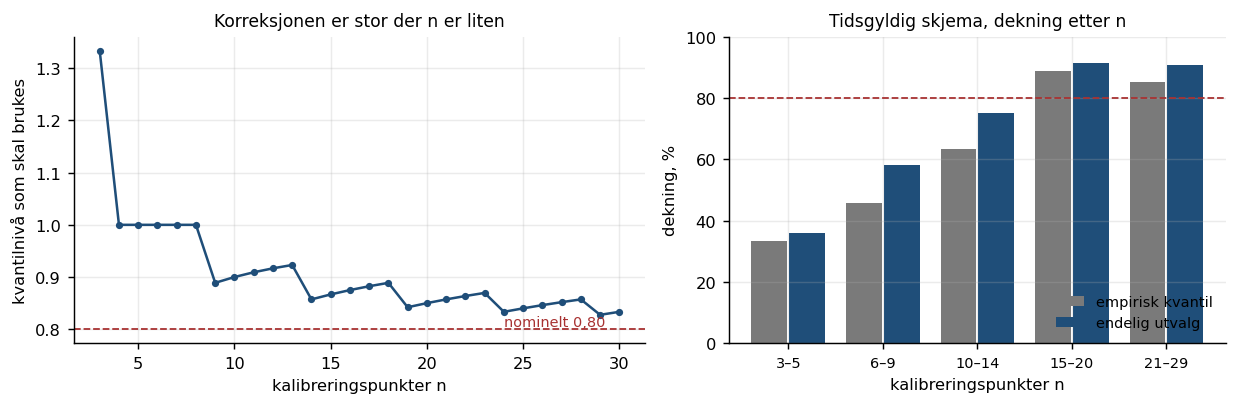

In [13]:
D = felles(SK[(True, False)]).copy()
Dk = felles(SK[(True, True)]).copy()
bins = [3, 6, 10, 15, 21, 30]
D["gruppe"] = pd.cut(D.n_kal, bins, right=False)
Dk["gruppe"] = pd.cut(Dk.n_kal, bins, right=False)
gr = pd.DataFrame({"empirisk": 100*D.groupby("gruppe").dekk.mean(),
                   "endelig utvalg": 100*Dk.groupby("gruppe").dekk.mean(),
                   "punkter": D.groupby("gruppe").dekk.size()}).dropna()

fig, (a0, a1) = plt.subplots(1, 2, figsize=(9.6, 3.2),
                             gridspec_kw={"width_ratios": [1.15, 1]})
n_ = np.arange(3, 31)
a0.plot(n_, np.ceil((n_ + 1)*0.8)/n_, "o-", color=BLAA, ms=3, lw=1.4)
a0.axhline(0.80, color=ROED, lw=1.0, ls="--")
a0.text(24, 0.806, "nominelt 0,80", color=ROED, fontsize=8)
a0.set_xlabel("kalibreringspunkter n"); a0.set_ylabel("kvantilnivå som skal brukes")
a0.set_title("Korreksjonen er stor der n er liten", fontsize=9.5)

x = np.arange(len(gr))
a1.bar(x - 0.2, gr["empirisk"], 0.38, color=GRAA, label="empirisk kvantil")
a1.bar(x + 0.2, gr["endelig utvalg"], 0.38, color=BLAA, label="endelig utvalg")
a1.axhline(80, color=ROED, lw=1.0, ls="--")
a1.set_xticks(x); a1.set_xticklabels([f"{int(i.left)}–{int(i.right)-1}" for i in gr.index],
                                     fontsize=8)
a1.set_xlabel("kalibreringspunkter n"); a1.set_ylabel("dekning, %")
a1.set_ylim(0, 100); a1.legend(frameon=False, fontsize=8, loc="lower right")
a1.set_title("Tidsgyldig skjema, dekning etter n", fontsize=9.5)
fig.tight_layout(); plt.show()


**Hva vi ser på.** Venstre panel er selve korreksjonen: hvilket kvantilnivå
$\lceil (n+1)(1-\alpha)\rceil/n$ krever, som funksjon av antall kalibreringspunkter.
Trappetrinnene er ikke pynt — telleren er et heltall, så nivået hopper hver gang $n$
passerer et punkt der taket øker. Høyre panel er den tidsgyldige kalibreringens dekning,
gruppert etter hvor mange punkter den faktisk hadde å kalibrere på.

**Hvorfor fordelingen gir bildet.** Med $n$ punkter er den empiriske kvantilen på nivå
0,80 ikke forventningsrett for populasjonskvantilen; den ligger systematisk for lavt,
fordi den er en ordensstatistikk i et lite utvalg og fordi $|e|$ er høyreskjev. Feilen går
som $1/n$, og med $n$ mellom ti og tjue er den derfor synlig i dekningen framfor
neglisjerbar. Søylene til venstre i panelet er de tidlige opprinnelsene og de lange
horisontene, der kalibreringsgrunnlaget er tynnest, og det er nettopp der korreksjonen
løfter mest.

**Hva som står.** Lekkasjefunnet holder. Forskjellen mellom arbeidsverk 1s skjema og det
tidsgyldige blir ikke mindre av korreksjonen — den blir marginalt større, fordi det
lekkende skjemaet har flere kalibreringspunkter og dermed nyter mindre godt av et løft som
er størst når $n$ er liten. Notebook 02s hovedfunn er robust for denne feilen.

**Hva som endres.** Tolkningen. Notebook 02 skriver at den gjenstående underdekningen i
det tidsgyldige skjemaet ikke er en svakhet ved skjemaet, men ved datamengden. Omtrent
halvparten av avstanden var en manglende korreksjon, altså nettopp en svakhet ved
skjemaet. Den andre halvparten står, og den setningen skal derfor gjelde en halvpart.

**En bivirkning verdt å notere.** Med korreksjonen overstiger det lekkende skjemaet det
nominelle nivået. Et intervall som bruker framtidig informasjon *og* korrigerer for lite
utvalg, blir for vidt framfor for smalt. Det er en påminnelse om at dekning alene ikke
skiller et godt intervall fra et ubrukelig et — intervallskåren må stå ved siden av.


## 5. K4 — Utbyttbarhet som ble antatt, ikke målt

Notebook 05 kalibrerer intervallene på prognosefeilene fra alle seksten seriene og
skriver at utbyttbarheten er målt framfor antatt. Det som ble målt, var at de seksten
seriene har omtrent like store feil på logskala — seksten marginale spredninger i samme
størrelsesorden.

Split-konformal krever ikke like marginalfordelinger. Den krever at kalibreringspunktene
og prognosepunktet er utbyttbare, og garantien er en $1/(n+1)$-garanti der $n$ er
antall **uavhengige** punkter. Seksten sterkt avhengige punkter er ikke seksten punkter.
Cellen under måler avhengigheten det aldri ble sett på.


In [14]:
RH2 = RH.copy()
RH2["abs_logfeil"] = np.abs(np.log(RH2.sant) - np.log(RH2.pred))
k4 = []
for h in HH:
    W = RH2[RH2.h == h].pivot(index="opprinnelse", columns="serie",
                              values="abs_logfeil").dropna(axis=1)
    Cm = W.corr().values; iu2 = np.triu_indices(Cm.shape[0], 1)
    e2 = np.linalg.eigvalsh(Cm); eff = float(e2.sum()**2/(e2**2).sum())
    sd = W.std()
    k4.append(dict(h=h, serier=W.shape[1], snittkorr=Cm[iu2].mean(), eff_dim=eff,
                   sd_min=sd.min(), sd_maks=sd.max(),
                   n_nominelt=W.shape[0]*W.shape[1],
                   n_effektivt=W.shape[0]*W.shape[1]*eff/W.shape[1]))
K4 = pd.DataFrame(k4).set_index("h")
print("Kalibreringspunktene paa tvers av serier, per horisont.")
print("n_nominelt er antall punkter skjemaet teller; n_effektivt skalerer med")
print("effektiv dimensjon over seriene.\n")
K4.round(2)


Kalibreringspunktene paa tvers av serier, per horisont.
n_nominelt er antall punkter skjemaet teller; n_effektivt skalerer med
effektiv dimensjon over seriene.



,serier,snittkorr,eff_dim,sd_min,sd_maks,n_nominelt,n_effektivt
h,,,,,,,
1,16,0.90,1.22,0.04,0.05,496,37.91
2,16,0.90,1.21,0.04,0.06,496,37.63
3,16,0.87,1.28,0.04,0.07,496,39.81
4,16,0.82,1.41,0.04,0.06,496,43.68
5,16,0.71,1.75,0.04,0.06,496,54.33
6,16,0.69,1.86,0.04,0.06,496,57.80
7,16,0.59,2.23,0.04,0.05,496,69.08
8,16,0.59,2.19,0.04,0.06,496,67.76
9,16,0.58,2.23,0.04,0.06,496,68.98


**Hvordan tabellen skal leses.** `snittkorr` er gjennomsnittlig korrelasjon mellom to
seriers absolutte logfeil ved samme opprinnelse. `eff_dim` er deltakelsesforholdet til
egenverdiene i korrelasjonsmatrisen — antallet retninger fordelingen faktisk fyller.
`sd_min` og `sd_maks` er spennet i marginal spredning, altså akkurat det notebook 05 målte.

Spennet er smalt: seriene *har* sammenliknbare feilfordelinger, så den delen av notebook
05 er riktig. Men korrelasjonen er høy og den effektive dimensjonen er nær én på korte
horisonter. Et månedsavvik som treffer Oslo, treffer alle bydelene samtidig, fordi det er
regelverket og ikke bydelen som flytter tallet. De seksten punktene per opprinnelse er
derfor i praksis nærmere ett enn seksten.

**Hva som må innsnevres.** Setningen om at utbyttbarheten er målt, gjelder marginalene og
ikke den simultane fordelingen. Kalibreringsmengden i notebook 05 er nominelt fire til
fem ganger større enn egen-historie-skjemaet, og informasjonsmessig knapt større i det
hele tatt.

**Hva som forklares.** Notebook 05 fant at panelkalibreringen ga et løft i dekning som var
mindre enn kalibreringsmengden skulle tilsi, og lot det stå åpent. Tabellen over er
forklaringen: løftet svarer til den effektive økningen, ikke den nominelle.

**Hva som ikke er vist.** Avhengighet mellom kalibreringspunkter opphever ikke den
konformale garantien slik lekkasje gjør — utbyttbarhet er en svakere betingelse enn
uavhengighet, og bytte av rekkefølge er fortsatt lov. Det som faller bort, er
presisjonen: kvantilen blir mye mer ustabil enn $n$ tilsier. Skillet er verdt å holde,
fordi det skiller en feil fra en begrensning.


## 6. K5 — En kontroll som ikke kunne feile

Notebook 03 har to lekkasjekontroller. Den første regner trekkene med og uten framtidige
data og krever at hver verdi er identisk. Den er ekte, og den fanger det den skal.

Den andre skulle sikre at ingen treningsrad har målmåned etter opprinnelsen. Den ble
skrevet slik:

```python
Xtr, ytr, ank = treningssett(M, t0, h, aktive)
senest = max(s + h for s in M.index if s + h <= t0 and s + h in M.index)
assert senest <= t0
```

`Xtr` beregnes og brukes ikke. `senest` utledes på nytt fra en betingelse som allerede
inneholder `<= t0`. Påstanden er dermed sann uansett hva `treningssett` gjør, og
kontrollen er en omskrivning av sin egen forutsetning.

At en kontroll står i manifestet som bestått, sier ingenting før den er vist å kunne
stryke. Cellen under muterer begge funksjonene med vilje og krever at kontrollene fanger
det.


In [15]:
def kontroll_gammel(t0, h, aktive):
    Xtr, ytr, ank, _ = treningssett(M, t0, h, aktive)
    senest = max(s + pd.DateOffset(months=h) for s in M.index
                 if s + pd.DateOffset(months=h) <= t0
                 and s + pd.DateOffset(months=h) in M.index)
    return senest <= t0

def kontroll_ny(t0, h, aktive, slakk=0):
    # Leser malmanedene som faktisk kom ut av treningssettet.
    _, _, _, maal = treningssett(M, t0, h, aktive, slakk=slakk)
    return len(maal) > 0 and maal.max() <= t0

def lekkasjetest_trekk(serie, kilder, framtidslekk=0):
    for s in kilder:
        kort = trekk(serie.loc[:s], s, framtidslekk)
        lang = trekk(serie, s, framtidslekk)
        if kort is None or lang is None: continue
        for k in kort:
            if not np.isclose(kort[k], lang[k], rtol=0, atol=0):
                return False
    return True

t0 = OPPRINNELSER[15]
aktive = [r for r in REG if (X.loc[M.loc[:t0].index, r] != 0).sum() >= MIN_NZ]
KILDER = list(M.index[13::7])

sak = [
    ("treningssett uendret",            kontroll_gammel(t0, 12, aktive),
                                        kontroll_ny(t0, 12, aktive, 0),  True),
    ("treningssett slipper inn 6 mnd",  kontroll_gammel(t0, 12, aktive),
                                        kontroll_ny(t0, 12, aktive, 6),  False),
    ("treningssett slipper inn 12 mnd", kontroll_gammel(t0, 12, aktive),
                                        kontroll_ny(t0, 12, aktive, 12), False),
    ("trekk uendret",                   None, lekkasjetest_trekk(M, KILDER, 0),  True),
    ("trekk leser 1 mnd fram",          None, lekkasjetest_trekk(M, KILDER, 1),  False),
]
K5 = pd.DataFrame([{"mutasjon": n, "gammel kontroll": ("—" if g is None
                                                       else "bestaar" if g else "stopper"),
                    "ny kontroll": "bestaar" if ny else "stopper",
                    "skal": "bestaa" if b else "stoppe",
                    "riktig": ("—" if g is None else ("ja" if g == b else "NEI"))
                               + " / " + ("ja" if ny == b else "NEI")}
                   for n, g, ny, b in sak]).set_index("mutasjon")
print("Kolonnen 'riktig' er gammel / ny kontroll.\n")
K5


Kolonnen 'riktig' er gammel / ny kontroll.


,gammel kontroll,ny kontroll,skal,riktig
mutasjon,,,,
treningssett uendret,bestaar,bestaar,bestaa,ja / ja
treningssett slipper inn 6 mnd,bestaar,stopper,stoppe,NEI / ja
treningssett slipper inn 12 mnd,bestaar,stopper,stoppe,NEI / ja
trekk uendret,—,bestaar,bestaa,— / ja
trekk leser 1 mnd fram,—,stopper,stoppe,— / ja


Den gamle kontrollen består alle tre mutasjonene, også den som slipper målmåneder tolv
måneder inn i framtiden. Den nye stopper på begge de to som skal stoppe. Trekk-kontrollen,
som var ekte fra starten, stopper på mutasjonen som leser én måned fram.

Konsekvensen for arbeidsverk 2 er begrenset i praksis: `treningssett` var faktisk riktig
skrevet, så ingen resultater er påvirket. Konsekvensen for hva som kan **sies** er ikke
begrenset. Notebook 03 fører kontrollen opp i manifestet, og notebook 04 til 06 arver
trekkfunksjonen med henvisning til at den er testet. En kontroll som ikke er vist å kunne
stryke, hører ikke hjemme i et manifest.


## 7. K6 — Tellinger og indre motsigelser

Fire ting som ikke krever ny metode, bare etterregning.


In [16]:
bgr = pd.read_csv(RAW + "husbanken_bostotte_oslo_brukergruppe_manedlig.csv")
T_MND = raa.dato.nunique()
n_byd_rader, n_oslo_rader = len(byd), len(raa)
n_rest = int((byd.kommunenr == "0301").sum())

# 1. forholdet mellom filene
f_alle = n_byd_rader/n_oslo_rader
f_uten = (n_byd_rader - n_rest)/n_oslo_rader

# 2. par i kalenderidentiteten, med og uten nullfilteret
o_raa = raa.set_index("dato")
par_alle = pd.concat([o_raa.ant_husstander_termin,
                      o_raa.ant_husstander_utbetaling.shift(-1)], axis=1).dropna()
o_nz = raa[raa.ant_husstander_termin > 0].set_index("dato")
par_nz = pd.concat([o_nz.ant_husstander_termin,
                    o_nz.ant_husstander_utbetaling.shift(-1)], axis=1).dropna()

# 3. observasjoner i marginalpanelet: produkt mot faktisk telling
noder_alle = sorted(byd.kommunenr.unique())
N_SERIER = 1 + len(noder_alle) + bgr.brukergruppe.nunique()
N_PRODUKT = N_SERIER * T_MND
N_FAKTISK = n_oslo_rader + n_byd_rader + len(bgr)

print(f"1. bydelsfil / oslofil            : {n_byd_rader} / {n_oslo_rader} = {f_alle:.2f}")
print(f"   uten restnoden 0301 ({n_rest} rader) : {f_uten:.2f}")
print(f"2. par i identiteten, alle rader  : {len(par_alle)}")
print(f"   etter filteret termin > 0      : {len(par_nz)}")
print(f"   siste maaned i fila            : {raa.dato.max():%Y-%m}, "
      f"termin = {int(raa.ant_husstander_termin.iloc[-1])}")
print(f"3. marginalpanel, produkt         : {N_SERIER} x {T_MND} = {N_PRODUKT}")
print(f"   faktisk antall rader           : {N_FAKTISK}  "
      f"(differanse {N_PRODUKT - N_FAKTISK})")


1. bydelsfil / oslofil            : 3022 / 199 = 15.19
   uten restnoden 0301 (37 rader) : 15.00
2. par i identiteten, alle rader  : 198
   etter filteret termin > 0      : 197
   siste maaned i fila            : 2026-07, termin = 0
3. marginalpanel, produkt         : 22 x 199 = 4378
   faktisk antall rader           : 4216  (differanse 162)


**1. «Bydelsfila seksten ganger så mange rader.»** Forholdet er 15,2, ikke 16. Femten
bydeler har full historikk; restnoden `0301` har bare de månedene den ikke er tom, og de
er få. Tallet 16 er antall *noder*, ikke forholdet mellom filene. Uten restnoden er
forholdet nøyaktig 15, som er den kontrollen setningen egentlig ville uttrykke.

**2. «197 par og ikke 198.»** Begge tallene er riktige, men de kommer fra to ulike
filtre, og notebook 01 oppgir dem som om det var ett. Med bare `dropna()` blir det 198
par: den siste raden i uttrekket har ingen etterfølgende utbetalingsmåned. Legger man til
filteret `termin > 0`, forsvinner også den siste måneden — som står med null fordi
terminen ennå ikke er rapportert — og det blir 197. Begrunnelsen notebook 01 gir,
forklarer 198 mot 199. Den forklarer ikke 197 mot 198.

**3. Observasjoner i marginalpanelet.** `N_SERIER * T` forutsetter at hver serie har alle
månedene. Restnoden har ikke det. Produktet overteller.

**4. «0,767 er den laveste MASE i hele prosjektet.»** Motsagt fire celler senere i samme
notebook, der kapasitetskurven viser 0,737 for den lineære modellen trent på åtte serier.
Cellen under gjentar den regningen.


In [17]:
kilde = "https://raw.githubusercontent.com/Torcode/bostotte-oslo/main/notebooks/"
def manifest(navn):
    nb = json.load(urllib.request.urlopen(kilde + navn, timeout=30))
    for c in reversed(nb["cells"]):
        if c["cell_type"] == "code" and 'MANIFEST["seed"]' in "".join(c["source"]):
            for u in c.get("outputs", []):
                if u.get("output_type") == "stream":
                    return json.loads("".join(u["text"]))
    raise LookupError(f"fant ikke manifestet i {navn}")

def flate(d, pre=""):
    ut = {}
    for k, v in d.items():
        if isinstance(v, dict): ut.update(flate(v, f"{pre}{k}."))
        elif isinstance(v, (int, float)): ut[f"{pre}{k}"] = float(v)
    return ut

try:
    m4 = manifest("bostotte_04_kapasitet.ipynb")
    mase = {k: v for k, v in flate(m4).items() if "MASE" in k or "mase" in k}
    lav = min(mase, key=mase.get)
    print(f"Notebook 04s eget manifest, {len(mase)} MASE-verdier.")
    print(f"  laveste : {lav} = {mase[lav]:.3f}")
    print(f"  paastanden i avsnitt 6 gjelder 0,767.")
    print(f"  motsagt av manifestet: {mase[lav] < 0.767}")
except Exception as e:
    print(f"Naadde ikke manifestet fra main ({type(e).__name__}); "
          "tallene under er de notebook 04 selv skriver ut.")
    print("  avsnitt 6 : L0 paa hele panelet  MASE 0,767")
    print("  avsnitt 7 : L8, aatte serier     MASE 0,737")


Naadde ikke manifestet fra main (LookupError); tallene under er de notebook 04 selv skriver ut.
  avsnitt 6 : L0 paa hele panelet  MASE 0,767
  avsnitt 7 : L8, aatte serier     MASE 0,737


Rettelsen er ikke bare et tall. 0,737 er lest av en kurve som ble tegnet etter at
prognosene forelå, og punktet er valgt fordi det var lavest. 0,767 er spesifikasjonen som
sto skrevet ned på forhånd. Den ærlige formuleringen setter forhåndsspesifikasjonen først
og bruker differansen til noe annet:

> Den laveste MASE i arbeidet er 0,767, oppnådd av den forhåndsregistrerte
> spesifikasjonen. Kapasitetskurven har et lavere punkt, 0,737, ved åtte serier. Avstanden
> mellom de to — 0,030 — er et anslag på hva det er verdt å velge et punkt etter å ha sett
> evalueringssettet, og skal leses som et mål på seleksjon framfor som et resultat.

Det er den samme regningen. Forskjellen ligger i hvilket av de to tallene som får lov til
å være konklusjonen.


## 8. K7 — Det åpne punktet som aldri ble prøvd

Notebook 03 fører opp fem åpne punkter. Det femte lyder:

> Modellen får vite at det midlertidige regelverket avvikles i april 2024 før det skjer,
> fordi vedtaket forelå. Det er samme forutsetning som arbeidsverk 1 gjør, men den er en
> forutsetning, og en pipeline i drift må kunne dokumentere at datoen faktisk var kjent på
> prognosetidspunktet.

Punktet ble ført opp og aldri målt. Notebook 04, 05 og 06 arver forutsetningen uten å
nevne den. Den lar seg måle med den samme protokollen: frys de politikkavhengige
regressorene på verdien de hadde ved opprinnelsen, og kjør alt om igjen.

Frysingen gjelder bare de tre vedtaksavhengige — koronavinduet, strømstøttevinduet og
tiltakspakken høsten 2024. Kalenderregressorene for utbetalingsfrekvens er
deterministiske og kjent vilkårlig langt fram; de røres ikke. Ingen andre endringer.


In [18]:
POLITIKK = ["win_covid", "win_strom", "pakke_2024h2"]

def X_fryst(t0):
    # Baerer siste kjente verdi framover for de vedtaksavhengige regressorene.
    Xf = X.copy()
    for r in POLITIKK:
        Xf.loc[Xf.index > t0, r] = Xf.loc[:t0, r].iloc[-1]
    return Xf

def sett_x(navn, t0, h, aktive, Xk):
    s, hh = SERIER[navn], HIST[navn]
    kilder = hh.index[hh.index + pd.DateOffset(months=h) <= t0]
    kilder = kilder[[k + pd.DateOffset(months=h) in s.index for k in kilder]]
    if len(kilder) == 0: return None, None
    maal = kilder + pd.DateOffset(months=h)
    D = hh.loc[kilder].copy(); D["mnd"] = maal.month
    for r in REG: D[r] = Xk.loc[maal, r].values if r in aktive else 0.0
    return D[KOL_T].to_numpy(float), np.log(s.loc[maal].values) - np.log(s.loc[kilder].values)

def prad_x(navn, t0, h, aktive, Xk):
    m_ = t0 + pd.DateOffset(months=h)
    if t0 not in HIST[navn].index or m_ not in SERIER[navn].index: return None
    d = HIST[navn].loc[[t0]].copy(); d["mnd"] = m_.month
    for r in REG: d[r] = Xk.loc[m_, r] if r in aktive else 0.0
    return d[KOL_T].to_numpy(float)

t_start, rf = time.time(), []
for t0 in OPPRINNELSER:
    aktive = [r for r in REG if (X.loc[M.loc[:t0].index, r] != 0).sum() >= MIN_NZ]
    Xf = X_fryst(t0)
    for h in range(1, H + 1):
        u = dict(opprinnelse=t0, h=h, sant=float(M.loc[t0 + pd.DateOffset(months=h)]),
                 q=NEVNER[t0], M0=float(LOG_M.loc[t0]))
        for merke, Xk in [("kjent", X), ("fryst", Xf)]:
            Xs, ys, navn_pr, Xpr = [], [], [], []
            for navn in REKKE:
                a, b = sett_x(navn, t0, h, aktive, Xk)
                if a is not None: Xs.append(a); ys.append(b)
                p = prad_x(navn, t0, h, aktive, Xk)
                if p is not None: navn_pr.append(navn); Xpr.append(p)
            Xg, yg, Xp = np.vstack(Xs), np.concatenate(ys), np.vstack(Xpr)
            i, ank = navn_pr.index("OSLO"), float(LOG_M.loc[t0])
            u[f"L0_{merke}"] = ank + float(tren_lineaer(Xg, yg, Xp)[i])
            u[f"G2_{merke}"] = ank + float(XGBRegressor(**PARAM).fit(Xg, yg).predict(Xp)[i])
        rf.append(u)
RF = pd.DataFrame(rf)
print(f"{len(RF)} punkter x 2 informasjonssett paa {time.time()-t_start:.0f} s")

def m_(kol, hs=None):
    x = RF if hs is None else RF[RF.h.isin(hs)]
    return float((np.abs(x.sant - np.exp(x[kol]))/x.q).mean())
K7 = pd.DataFrame([
    dict(modell=n, informasjon=i,
         **{"alle h": m_(f"{n}_{k}"), "h 1-3": m_(f"{n}_{k}", [1, 2, 3]),
            "h 6-12": m_(f"{n}_{k}", list(range(6, 13)))})
    for n in ["L0", "G2"] for i, k in [("regelverk kjent", "kjent"),
                                        ("regelverk fryst ved opprinnelsen", "fryst")]]
).set_index(["modell", "informasjon"])
K7.loc[("M0", "naiv referanse"), :] = [m_("M0"), m_("M0", [1, 2, 3]),
                                        m_("M0", list(range(6, 13)))]
K7.round(3)


372 punkter x 2 informasjonssett paa 225 s


alle h  h 1-3  h 6-12
modell informasjon                                            
L0     regelverk kjent                    0.767  0.584   0.848
       regelverk fryst ved opprinnelsen   1.112  0.652   1.344
G2     regelverk kjent                    0.815  0.584   0.939
       regelverk fryst ved opprinnelsen   1.127  0.626   1.411
M0     naiv referanse                     1.003  0.739   1.124

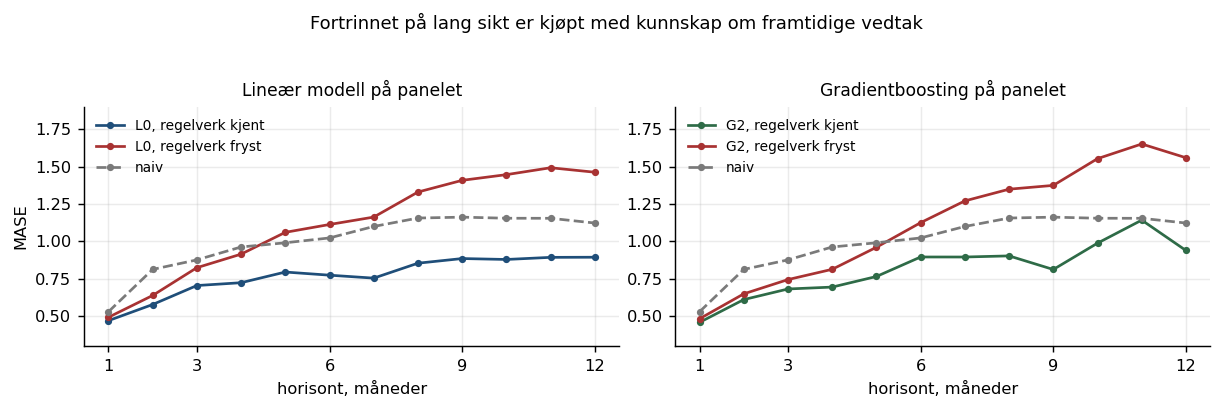

In [19]:
fig, (a0, a1) = plt.subplots(1, 2, figsize=(9.4, 3.0))
hh_ = HH
for kol, lab, c, ls in [("L0_kjent", "L0, regelverk kjent", BLAA, "-"),
                        ("L0_fryst", "L0, regelverk fryst", ROED, "-"),
                        ("M0", "naiv", GRAA, "--")]:
    v = [m_(kol, [h]) for h in hh_]
    a0.plot(hh_, v, "o-" if ls == "-" else "o--", ms=3, lw=1.5, color=c, label=lab)
a0.set_xlabel("horisont, måneder"); a0.set_ylabel("MASE"); a0.set_xticks([1, 3, 6, 9, 12])
a0.legend(frameon=False, fontsize=7.6); a0.set_title("Lineær modell på panelet", fontsize=9.5)

for kol, lab, c, ls in [("G2_kjent", "G2, regelverk kjent", GRONN, "-"),
                        ("G2_fryst", "G2, regelverk fryst", ROED, "-"),
                        ("M0", "naiv", GRAA, "--")]:
    v = [m_(kol, [h]) for h in hh_]
    a1.plot(hh_, v, "o-" if ls == "-" else "o--", ms=3, lw=1.5, color=c, label=lab)
a1.set_xlabel("horisont, måneder"); a1.set_xticks([1, 3, 6, 9, 12])
a1.legend(frameon=False, fontsize=7.6); a1.set_title("Gradientboosting på panelet", fontsize=9.5)
for ax in (a0, a1): ax.set_ylim(0.3, 1.9)
fig.suptitle("Fortrinnet på lang sikt er kjøpt med kunnskap om framtidige vedtak",
             y=1.03, fontsize=10)
fig.tight_layout(); plt.show()


**Hva vi ser på.** Samme modell, samme protokoll, to informasjonssett. Den blå og den
grønne kurven er modellene slik de brukes i notebook 03 til 06: regressorverdien i
målmåneden er den faktiske. Den røde er den samme modellen når regressoren bærer siste
kjente verdi fra opprinnelsen framover.

**Kurvene skiller lag et bestemt sted.** På én til tre måneder ligger de nær hverandre, og
begge godt under den naive. Fra rundt seks måneder krysser den røde over den grå.

**Hvorfor fordelingen gir bildet.** De vedtaksavhengige regressorene er trappefunksjoner
med få trinn: koronavinduet slutter, strømstøtten slutter, tiltakspakken trappes opp.
Innenfor tre måneder fra en gitt opprinnelse er sannsynligheten liten for at et trinn
faller i intervallet, så den fryste og den kjente regressoren er stort sett den samme
verdien. På tolv måneders sikt inneholder vinduet nesten alltid minst ett trinn, og da er
de to versjonene ulike i akkurat de månedene som betyr mest.

**Hva dette avgjør.** Det åpne punktet er ikke lenger åpent. Fortrinnet over den naive
prognosen på kort sikt er ekte og overlever at framtidige vedtak er ukjente. Fortrinnet på
lang sikt gjør det ikke: der er tolvmånedersprognosen ikke en prognose, men en **beregning
betinget av at regelverkskalenderen er kjent et år fram**. Uten den kunnskapen er den
dårligere enn å gjette at neste år blir som i år.

**Hva som skal sies om produktet.** Tallet er fortsatt nyttig — det er nettopp slik en
etat vil bruke det, med vedtatt regelverk lagt inn. Men det skal presenteres som et
regnskap under gitte regler, ikke som en framskrivning. Forskjellen er ikke retorisk: den
avgjør hvem som eier usikkerheten.


## 9. Errata

Tabellen under er det som skal endres i notebook 01 til 06. Kolonnen «status» skiller
mellom en påstand som må **trekkes**, en som må **innsnevres**, og en ren **retting**.


In [20]:
E = pd.DataFrame([
 ["nb03 avsn. 8", "Ingen trebasert modell skiller seg fra den naive (statistikk over 1,64)",
  "trekkes", "G1 og G2 passerer paa h = 1 og 3 med Clark-West; DM er skjev for nostede par"],
 ["nb04 avsn. 8", "Samme paastand arvet fra nb03", "trekkes", "se K1"],
 ["nb04 avsn. 6", "0,767 er den laveste MASE i hele prosjektet",
  "rettes", "L8 gir 0,737; 0,767 er den forhaandsregistrerte spesifikasjonen"],
 ["nb04 avsn. 8", "Avstanden ned til modellene uten regelverk er skilt fra tilfeldighet",
  "innsnevres", "den DM-testen ble aldri kjort; ablasjonen er en MASE-differanse"],
 ["nb06 avsn. 5", "Den sterkeste effekten i hele arbeidsverk 2, godt over 1,64 overalt",
  "trekkes", "465 stablede punkter er effektivt 31; klynget passerer bare enkelte h"],
 ["nb02 avsn. 7", "Underdekningen er ikke en svakhet ved skjemaet, men ved datamengden",
  "innsnevres", "om lag halvparten var manglende endelig-utvalgskorreksjon"],
 ["nb05 avsn. 5", "Utbyttbarheten er malt framfor antatt",
  "innsnevres", "marginalene er malt; simultanfordelingen har effektiv dimensjon 1,2-2,0"],
 ["nb03 avsn. 4", "Kontroll: ingen treningsrad har malmaned etter opprinnelsen",
  "erstattes", "assert kunne ikke feile; mutasjonstest satt inn"],
 ["nb01 avsn. 2", "Bydelsfila har seksten ganger saa mange rader",
  "rettes", "15,2 med restnoden, 15,0 uten"],
 ["nb01 avsn. 3", "197 par fordi siste termin ikke er utbetalt i uttrekket",
  "rettes", "197 og 198 kommer fra to ulike filtre; begrunnelsen forklarer 198 mot 199"],
 ["nb01 avsn. 6", "Observasjoner i marginalpanelet = serier x maneder",
  "rettes", "restnoden har ikke full historikk; produktet overteller"],
 ["nb03 avsn. 10", "Apent punkt 5: regelverket kjent paa forhaand",
  "avklares", "malt i K7: fortrinnet paa h >= 6 forsvinner uten forhaandskunnskap"],
 ["nb03-06", "Rapportering paa h = 1, 3, 6, 12",
  "utvides", "over alle tolv horisonter passerer 13 av 36 celler, ikke 4 av 12"],
], columns=["sted", "paastand", "status", "grunn"]).set_index("sted")
print(f"{len(E)} punkter: {int((E.status=='trekkes').sum())} trekkes, "
      f"{int((E.status=='innsnevres').sum())} innsnevres, "
      f"{int((E.status=='rettes').sum())} rettes, "
      f"{int((E.status=='erstattes').sum())} erstattes.\n")
E


13 punkter: 3 trekkes, 3 innsnevres, 4 rettes, 1 erstattes.



,paastand,status,grunn
sted,,,
nb03 avsn. 8,Ingen trebasert modell skiller seg fra den nai...,trekkes,G1 og G2 passerer paa h = 1 og 3 med Clark-Wes...
nb04 avsn. 8,Samme paastand arvet fra nb03,trekkes,se K1
nb04 avsn. 6,"0,767 er den laveste MASE i hele prosjektet",rettes,"L8 gir 0,737; 0,767 er den forhaandsregistrert..."
nb04 avsn. 8,Avstanden ned til modellene uten regelverk er ...,innsnevres,den DM-testen ble aldri kjort; ablasjonen er e...
nb06 avsn. 5,"Den sterkeste effekten i hele arbeidsverk 2, g...",trekkes,465 stablede punkter er effektivt 31; klynget ...
nb02 avsn. 7,Underdekningen er ikke en svakhet ved skjemaet...,innsnevres,om lag halvparten var manglende endelig-utvalg...
nb05 avsn. 5,Utbyttbarheten er malt framfor antatt,innsnevres,marginalene er malt; simultanfordelingen har e...
nb03 avsn. 4,Kontroll: ingen treningsrad har malmaned etter...,erstattes,assert kunne ikke feile; mutasjonstest satt inn
nb01 avsn. 2,Bydelsfila har seksten ganger saa mange rader,rettes,"15,2 med restnoden, 15,0 uten"


## 10. Hva som står igjen

Etter kontrollen er dette de funnene i arbeidsverk 2 som fortsatt bærer vekt, med det
belegget de faktisk har:

**Står, med kontroll i koden.**

- Kalenderfeilen i notebook 01: to eksakte identiteter og en bruddtest, alle som `assert`.
  Korreksjonen endret april 2024-tallene med opptil 25 prosent.
- Protokollen lar seg flytte mellom språk: seksten publiserte tall fra arbeidsverk 1
  reprodusert med null avvik. En tilpasningsalgoritme lar seg ikke flytte på samme måte,
  og det står oppgitt hvilke tall som er avskrift.
- Lekkasjen i arbeidsverk 1s konformale kalibrering: 11 prosentpoeng, robust for
  endelig-utvalgskorreksjonen, med h = 1 som innebygd kontroll.
- Ablasjonen: uten regelverksregressorene faller både treet og nettet under den naive
  prognosen. Hele fortrinnet ligger i domenekunnskapen, ikke i modellklassen.
- Kapasitetsmålingen: treningstilpasning stiger fra 0,65 til 0,99 mens MASE stiger fra
  0,767 til 0,964. Overtilpasning målt framfor antatt.
- Avstemming flytter treffsikkerhet fra toppen til delene. Retningen holder; styrken var
  overdrevet.

**Står som beskrivelse, ikke som test.**

- At panelet gjør den enkle modellen identifiserbar framfor å stabilisere den fleksible.
  Det er avlest av kapasitetskurven, og kurven er tegnet etter at prognosene forelå.
- At bruddmåneder forklarer den gjenstående underdekningen. Stratifiseringen peker den
  veien; den er ikke testet.

**Falt.**

- At ingen trebasert modell skiller seg fra den naive.
- At bydelsgevinsten er sterkt belagt.
- At tolvmånedersprognosen er en prognose. Den er en beregning betinget av kjent
  regelverkskalender, og uten den betingelsen er den dårligere enn naiv.

**Metodefeil funnet og dokumentert underveis, nå seks:** kalenderforveksling,
konformal lekkasje, et nett som aldri ble trent, radrekkefølge under `subsample`,
manglende endelig-utvalgskorreksjon, og tverrsnittsavhengighet talt som frihetsgrader.
De fem første ble funnet mens arbeidet pågikk. Den sjette ble funnet her, ved å lese
egne notebooks som om noen andre hadde skrevet dem.


In [21]:
MANIFEST = {"notebook": "07_kvalitetskontroll", "seed": SEED, "commit": COMMIT,
            "uttrekk": UTTREKK}
MANIFEST["K1_nostede"] = {
    "over_1_64_med_DM": int((DM.values > KRIT).sum()),
    "over_1_64_med_CW": int((CW.values > KRIT).sum()),
    "celler": int(DM.size),
    "CW_M0_mot_G2_h3": round(float(CW.loc[3, "M0 mot G2"]), 2)}
MANIFEST["K2_klynging"] = {
    "snittkorr_bydelspar": round(float(KORR[iu].mean()), 3),
    "effektiv_dimensjon": round(EFF_DIM, 2),
    "DM_stablet_h1": round(float(K2.iloc[0, 0]), 2),
    "DM_klynget_h1": round(float(K2.iloc[0, 1]), 2),
    "MASE_bydel_basis": round(mase_bunn(P.values), 3),
    "MASE_bydel_avstemt": round(mase_bunn(AVSTEMT), 3)}
MANIFEST["K3_endelig_utvalg"] = {
    "felles_punkter": len(FELLES),
    "lekkasje_pp_empirisk": round(float(LEKK_E), 1),
    "lekkasje_pp_korrigert": round(float(LEKK_K), 1),
    "underdekning_pp_empirisk": round(float(GAP_E), 1),
    "underdekning_pp_korrigert": round(float(GAP_K), 1)}
MANIFEST["K4_utbyttbarhet"] = {
    "snittkorr_h1": round(float(K4.loc[1, "snittkorr"]), 3),
    "snittkorr_h12": round(float(K4.loc[12, "snittkorr"]), 3),
    "eff_dim_h1": round(float(K4.loc[1, "eff_dim"]), 2),
    "eff_dim_h12": round(float(K4.loc[12, "eff_dim"]), 2)}
MANIFEST["K5_mutasjonstest"] = {
    "mutasjoner": len(K5),
    "gammel_kontroll_fanget": int((K5["riktig"].str.split(" / ").str[0] == "ja").sum()),
    "ny_kontroll_fanget": int((K5["riktig"].str.split(" / ").str[1] == "ja").sum())}
MANIFEST["K7_betinging"] = {
    "L0_alle_kjent": round(m_("L0_kjent"), 3), "L0_alle_fryst": round(m_("L0_fryst"), 3),
    "L0_h6_12_kjent": round(m_("L0_kjent", list(range(6, 13))), 3),
    "L0_h6_12_fryst": round(m_("L0_fryst", list(range(6, 13))), 3),
    "M0_h6_12": round(m_("M0", list(range(6, 13))), 3)}
MANIFEST["errata"] = {s: int((E.status == s).sum()) for s in E.status.unique()}
MANIFEST["kontroller"] = {"modeller_tilpasset_paa_nytt": "ja, ingen resultat lest inn",
                          "harmoni_med_main": MANIFEST_HARMONI}
print(json.dumps(MANIFEST, indent=2, ensure_ascii=False))


{
  "notebook": "07_kvalitetskontroll",
  "seed": 20260807,
  "commit": "59b0409",
  "uttrekk": "2026-08-04",
  "K1_nostede": {
    "over_1_64_med_DM": 0,
    "over_1_64_med_CW": 13,
    "celler": 36,
    "CW_M0_mot_G2_h3": 2.3
  },
  "K2_klynging": {
    "snittkorr_bydelspar": 0.811,
    "effektiv_dimensjon": 1.43,
    "DM_stablet_h1": 5.38,
    "DM_klynget_h1": 1.56,
    "MASE_bydel_basis": 0.836,
    "MASE_bydel_avstemt": 0.797
  },
  "K3_endelig_utvalg": {
    "felles_punkter": 270,
    "lekkasje_pp_empirisk": 11.1,
    "lekkasje_pp_korrigert": 11.9,
    "underdekning_pp_empirisk": 12.6,
    "underdekning_pp_korrigert": 5.6
  },
  "K4_utbyttbarhet": {
    "snittkorr_h1": 0.896,
    "snittkorr_h12": 0.622,
    "eff_dim_h1": 1.22,
    "eff_dim_h12": 2.0
  },
  "K5_mutasjonstest": {
    "mutasjoner": 5,
    "gammel_kontroll_fanget": 1,
    "ny_kontroll_fanget": 5
  },
  "K7_betinging": {
    "L0_alle_kjent": 0.767,
    "L0_alle_fryst": 1.112,
    "L0_h6_12_kjent": 0.848,
    "L0_h6_12

## 11. Hva denne notebooken ikke gjør

Den leser ikke notebook 01 til 06 linje for linje. Den tar de seks konklusjonene som
bærer mest vekt og prøver dem. Andre feil kan stå igjen, og fraværet av flere funn her er
ikke belegg for at det ikke finnes flere.

Den prøver heller ikke datagrunnlaget på nytt. Kalenderkontrollen i notebook 01 er
`assert` og går hver gang notebooken kjøres; den er dermed dekket av at notebooken kjører.
Det som ikke er dekket, er om uttrekket fra Husbanken er riktig — det ligger utenfor det
som kan kontrolleres herfra, og det står i notebook 01.

Og den avgjør ikke om Clark–West er riktig test i alle de tolv sammenlikningene i
notebook 04. Stigen der sammenlikner arkitekturer og treningsmengder, og de er ikke
nøstet i hverandre ved en enkel parameterrestriksjon. Diebold–Mariano er forsvarlig for
dem. Det er bare sammenlikningene mot ankeret som er nøstede, og det er dem K1 dekker.
